# Zenti Macro Dataset — OPTICS Clustering & Pair Selection

**Goal:** Cluster the 42 Bloomberg macro features using OPTICS, then run a cointegration-based pair selection algorithm within each cluster.  
**Output:** `total_pairs_zenti.pkl` — list of valid cointegrated pairs for downstream LSTM training.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from arch.unitroot import ADF
from hurst import compute_Hc

from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.cluster import OPTICS
from sklearn.manifold import TSNE

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

## 2. Data Loading

We load the Excel dataset (`Zenti Exercises May 2024.xlsx`) which contains:
- **Sheet `Markets`**: 1111 weekly observations (Jan 2000 – Apr 2021), 42 Bloomberg macro features + binary label `Y`
- **Sheet `Metadata`**: human-readable description and asset type for each variable

The label `Y` is separated from the features: `Y=0` means risk-on (normal market), `Y=1` means risk-off (stress event). We also build a `feature_types` lookup from the Metadata sheet so we can colour-code plots by asset class.

In [2]:
DATA_PATH = '/Users/nico/Desktop/GSOM/New Tech/Project/Zenti Exercises May 2024.xlsx'
OUTPUT_PATH = '/Users/nico/Desktop/GSOM/New Tech/Project/'

df_raw  = pd.read_excel(DATA_PATH, sheet_name='Markets',  index_col=0, parse_dates=True)
df_meta = pd.read_excel(DATA_PATH, sheet_name='Metadata')

df_prices = df_raw.drop(columns=['Y'])
y_labels  = df_raw['Y']

# Build asset-type lookup from Metadata
type_map = dict(zip(df_meta['Variable name'].str.strip(), df_meta['Type']))
type_map['XAUBGNL'] = 'Commodity'   # metadata key is 'XAU BGNL' with a space; column has none
feature_types = {col: type_map.get(col, 'Unknown') for col in df_prices.columns}

print(f'Dataset shape : {df_raw.shape}')
print(f'Date range    : {df_prices.index[0].date()} → {df_prices.index[-1].date()}')
print(f'Null values   : {df_prices.isna().sum().sum()}')
print(f'Y distribution: {y_labels.value_counts().to_dict()}  (0=risk-on, 1=risk-off)')

Dataset shape : (1111, 43)
Date range    : 2000-01-11 → 2021-04-20
Null values   : 0
Y distribution: {0: 874, 1: 237}  (0=risk-on, 1=risk-off)


In [3]:
def shade_risk_off(ax, y_labels, alpha=0.15, color='red'):
    """Shade contiguous Y=1 (risk-off) periods on ax. Call ax.legend() after to add patch entry."""
    in_ro, start = False, None
    for date, val in y_labels.items():
        if val == 1 and not in_ro:
            start, in_ro = date, True
        elif val == 0 and in_ro:
            ax.axvspan(start, date, alpha=alpha, color=color, label='_nolegend_')
            in_ro = False
    if in_ro:
        ax.axvspan(start, y_labels.index[-1], alpha=alpha, color=color, label='_nolegend_')

## 3. Exploratory Data Analysis (EDA)

Before running any model, we visualise the data to build intuition:
- **3.1** Feature overview table (min/max/mean by asset class)
- **3.2** Timeline of risk-off episodes overlaid on key price series
- **3.3** Cumulative % change per asset class — shows how different instruments trend over 20 years
- **3.4** Correlation heatmap sorted by asset class — helps anticipate which pairs might co-move
- **3.5** ADF stationarity pre-check on price levels — confirms most series are I(1) as expected

### 3.1 Feature Overview Table

In [4]:
summary = df_prices.describe().T.drop('count', axis=1).round(4)
summary['Type'] = summary.index.map(feature_types)
summary = (
    summary
    .reset_index()
    .rename(columns={'index': 'Feature'})
    .sort_values(['Type', 'Feature'])
    .set_index('Feature')
)
display(summary)





,mean,std,min,25%,50%,75%,max,Type
Feature,,,,,,,,
EMUSTRUU,704.3795,309.9518,230.5267,434.6607,714.8071,939.8246,1286.3530,Bond Index
LF94TRUU,259.0527,75.9344,121.3310,205.3156,264.7702,320.7532,398.7065,Bond Index
LF98TRUU,1231.2581,553.1210,491.0800,743.5350,1145.1500,1663.9450,2378.5300,Bond Index
LG30TRUU,804.7206,370.2520,294.3674,479.3883,765.2479,1111.2243,1525.7900,Bond Index
LMBITR,883.6154,241.5071,472.7233,683.8967,855.5171,1099.7055,1350.5000,Bond Index
LP01TREU,232.1099,109.9176,80.7968,131.0250,213.2052,342.8846,431.5528,Bond Index
LUACTRUU,2077.3069,690.7318,986.9400,1509.7300,2045.5500,2624.9800,3550.4300,Bond Index
LUMSTRUU,1637.2935,417.2293,869.3300,1251.1300,1723.8000,2005.3300,2325.8600,Bond Index
GT10,3.2667,1.3325,0.5080,2.1955,3.1150,4.3450,6.7480,Bond Yield


### 3.2 Y Label Distribution Over Time

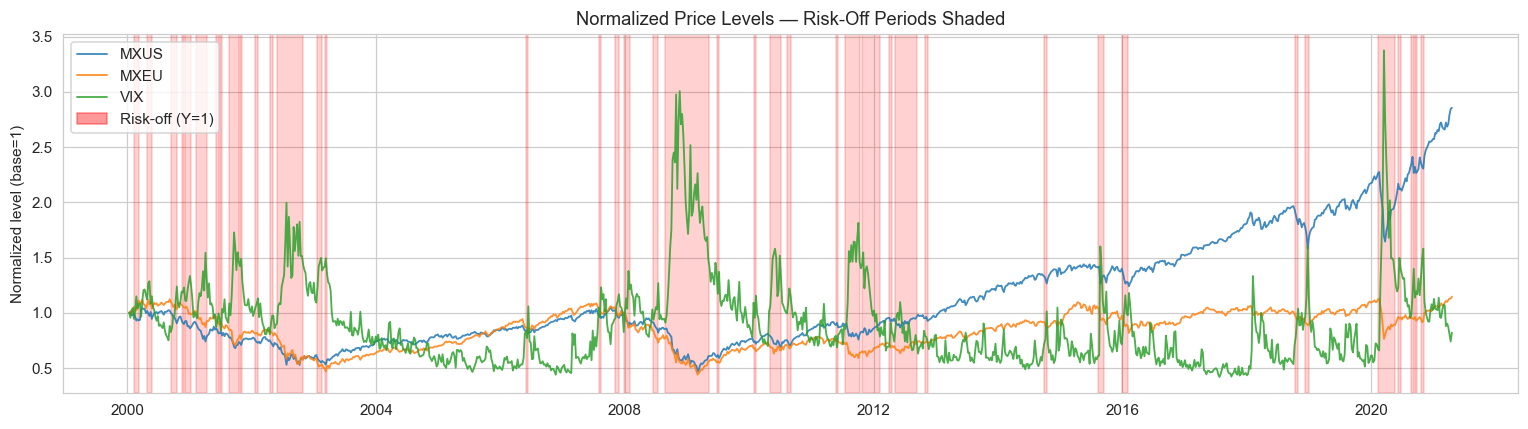

Risk-off weeks : 237 / 1111 (21.3%)


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

for col in ['MXUS', 'MXEU', 'VIX']:
    normalized = df_prices[col] / df_prices[col].iloc[0]
    ax.plot(df_prices.index, normalized, label=col, alpha=0.85, linewidth=1.2)

shade_risk_off(ax, y_labels, alpha=0.18)

handles, labels = ax.get_legend_handles_labels()
handles.append(mpatches.Patch(color='red', alpha=0.4, label='Risk-off (Y=1)'))
ax.legend(handles=handles, loc='upper left')
ax.set_title('Normalized Price Levels — Risk-Off Periods Shaded')
ax.set_ylabel('Normalized level (base=1)')
plt.tight_layout()
plt.show()

print(f"Risk-off weeks : {y_labels.sum()} / {len(y_labels)} ({y_labels.mean()*100:.1f}%)")

### 3.3 Price Level Time Series per Asset Class

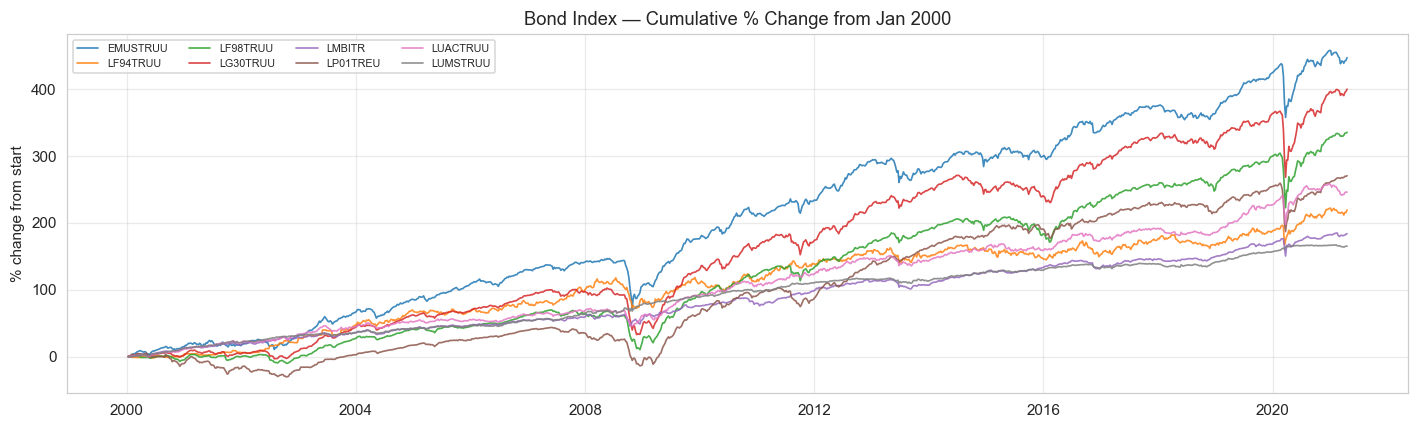

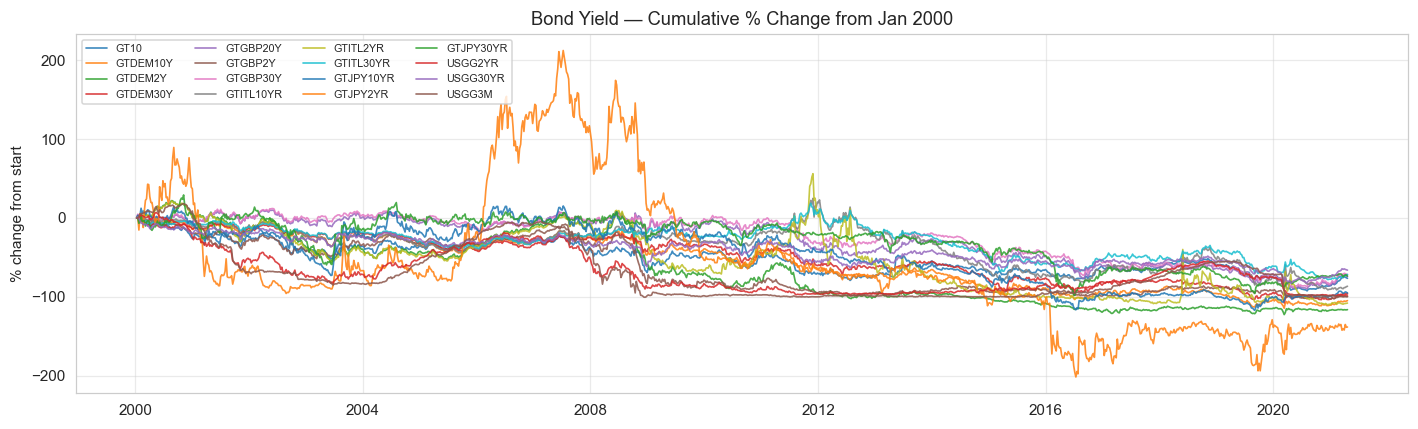

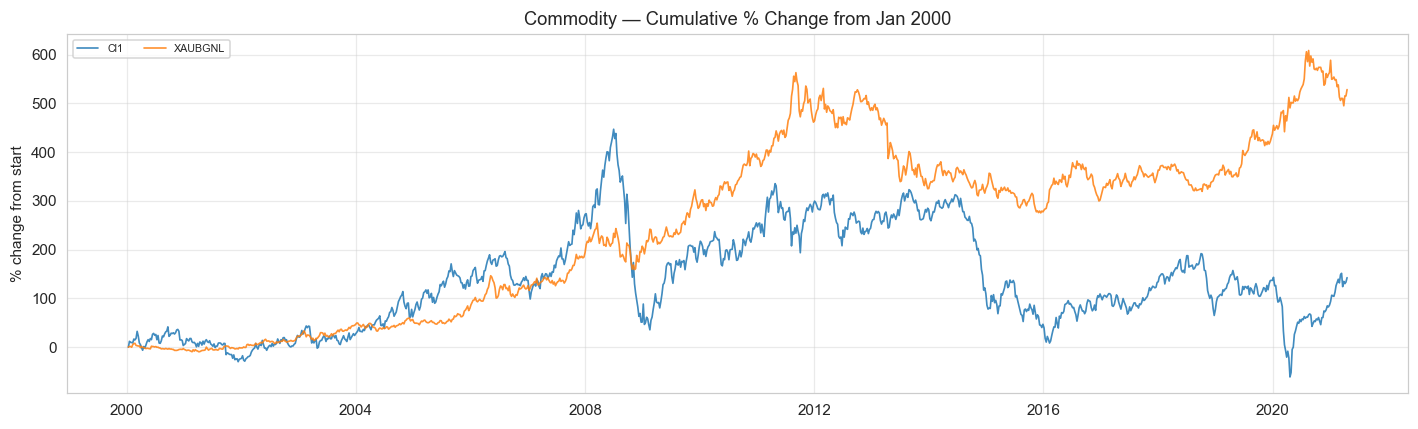

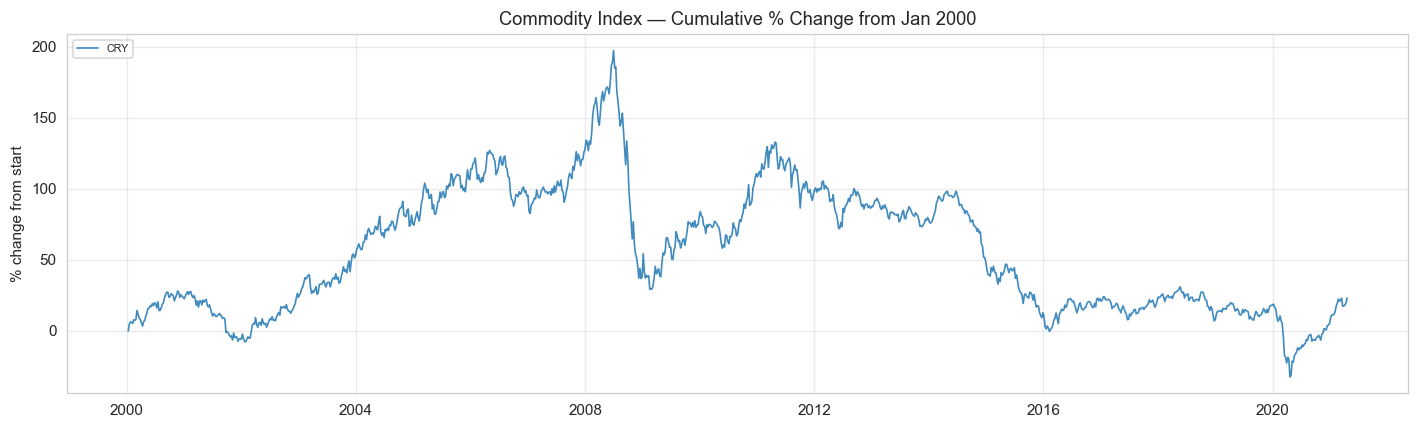

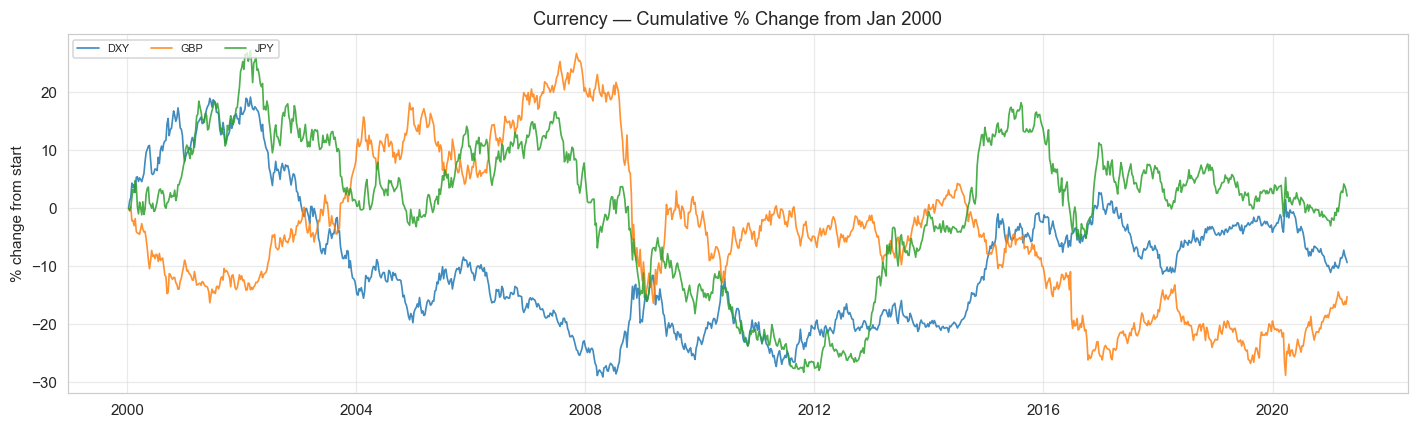

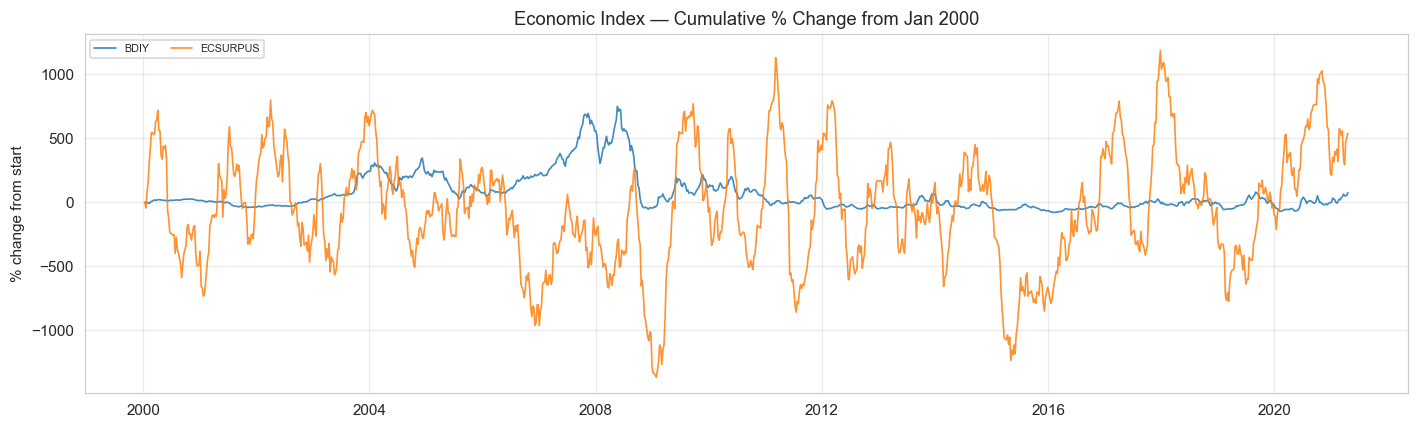

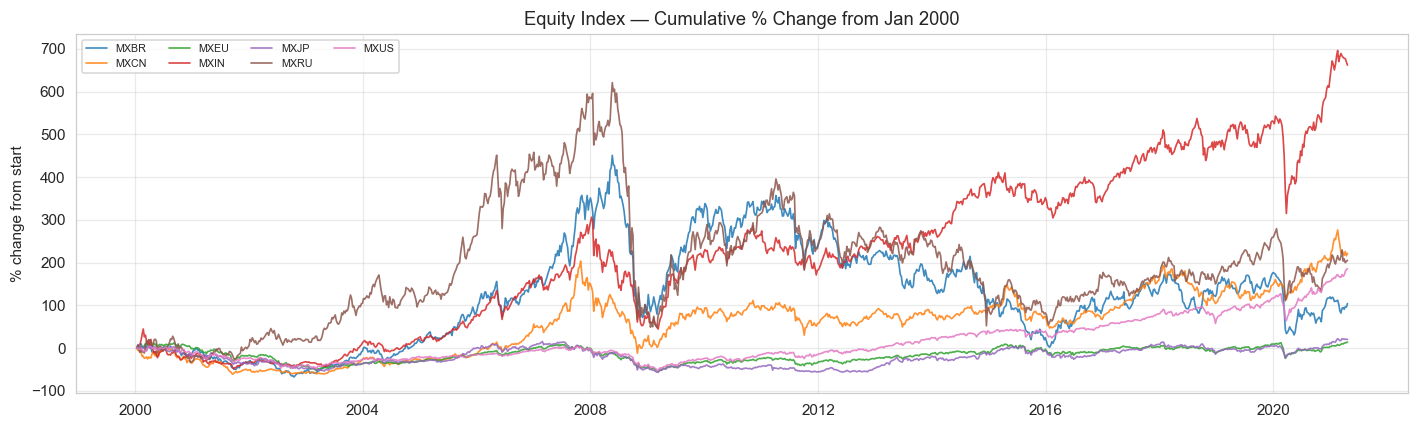

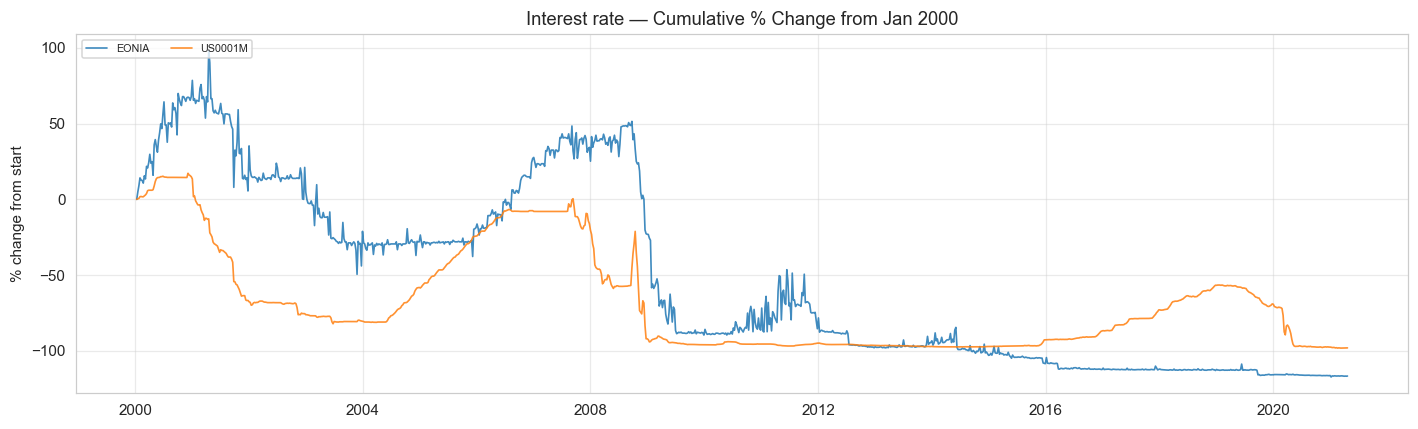

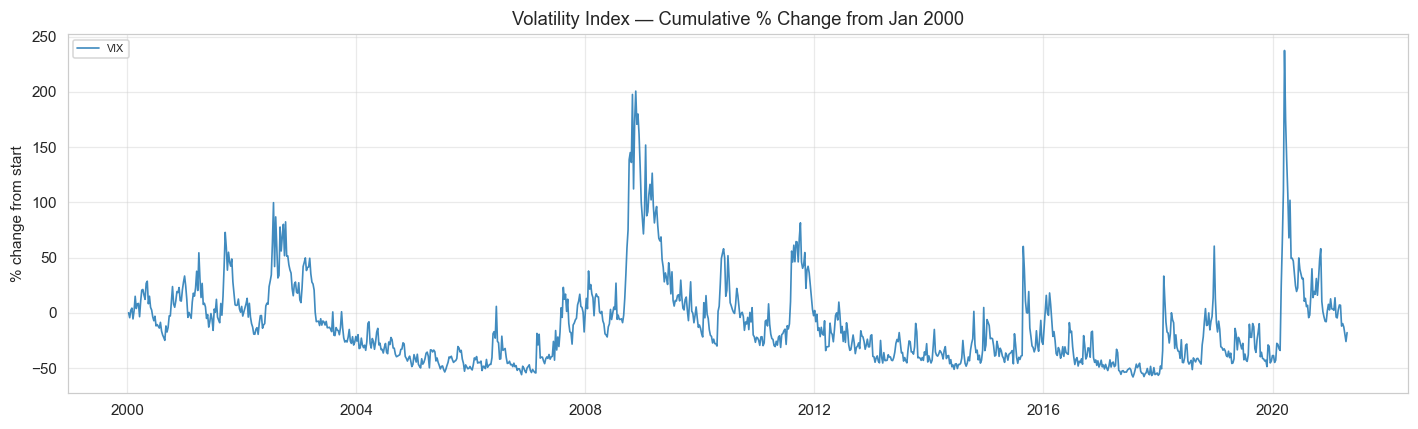

In [6]:
asset_classes = sorted(set(feature_types.values()))

for atype in asset_classes:
    cols = [c for c, t in feature_types.items() if t == atype]
    if not cols:
        continue

    fig, ax = plt.subplots(figsize=(13, 4))
    for col in cols:
        series = df_prices[col]
        normalized = (series - series.iloc[0]) / series.iloc[0] * 100
        ax.plot(df_prices.index, normalized, label=col, linewidth=1.1, alpha=0.85)

    ax.set_title(f'{atype} — Cumulative % Change from Jan 2000')
    ax.set_ylabel('% change from start')
    ax.legend(loc='upper left', fontsize=7, ncol=min(4, len(cols)))
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

### 3.4 Correlation Heatmap (sorted by asset type)

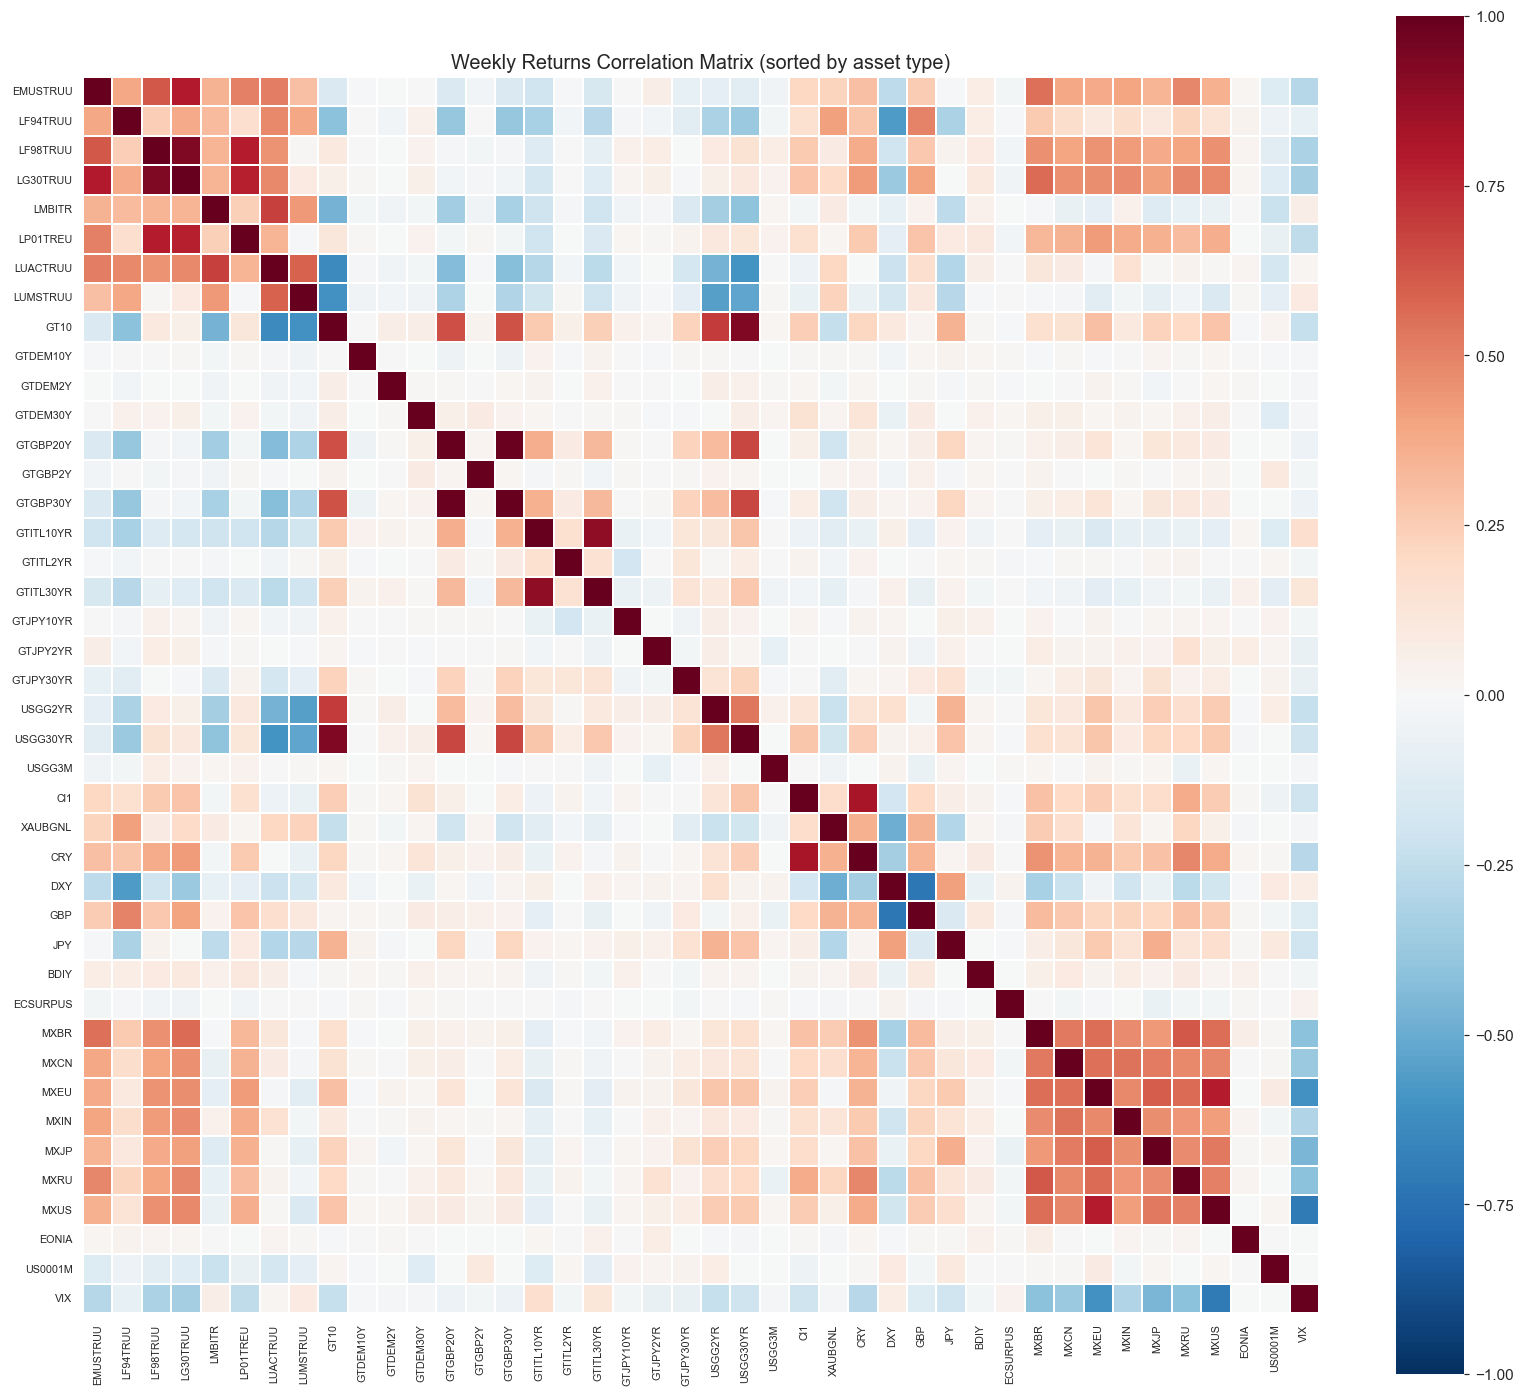

In [7]:
df_returns = df_prices.pct_change().iloc[1:].replace([np.inf, -np.inf], np.nan).fillna(0)

corr = df_returns.corr()

# Sort columns by asset type for visual block structure
order = sorted(df_returns.columns, key=lambda c: (feature_types.get(c, 'ZZZ'), c))

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(
    corr.loc[order, order],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    xticklabels=True, yticklabels=True,
    ax=ax
)
ax.set_title('Weekly Returns Correlation Matrix (sorted by asset type)', fontsize=13)
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()
plt.show()

### 3.5 Stationarity Pre-check (ADF on Price Levels)

Cointegration only makes sense between two **I(1)** series (random walks). We run the Augmented Dickey-Fuller test on every price level to verify this assumption formally:
- `H0`: the series has a unit root (non-stationary)
- We **want to keep** the null → p-value > 0.10 means non-stationary → eligible for pair selection
- Series that reject H0 (p < 0.10, e.g. VIX, ECSURPUS) are already stationary and will be excluded from all pairs

The results are cached in `adf_cache` and reused in the pair selection loop to avoid recomputing ADF for the same column multiple times.

In [8]:
adf_cache = {}   # col → ADF p-value; reused in the pair selection loop
adf_results = []

for col in df_prices.columns:
    base = {'Feature': col, 'Type': feature_types.get(col, 'Unknown')}
    try:
        adf = ADF(df_prices[col].values)
        adf_cache[col] = adf.pvalue
        base |= {'ADF p-val': round(adf.pvalue, 4), 'Non-stationary (p>0.10)': adf.pvalue > 0.10}
    except Exception:
        adf_cache[col] = np.nan
        base |= {'ADF p-val': None, 'Non-stationary (p>0.10)': None}
    adf_results.append(base)

adf_df = pd.DataFrame(adf_results).sort_values('ADF p-val', ascending=False)
n_nonstat = adf_df['Non-stationary (p>0.10)'].sum()
print(f"{n_nonstat}/{len(adf_df)} features are non-stationary (I(1)) — eligible for pair selection\n")
display(adf_df.reset_index(drop=True))

37/42 features are non-stationary (I(1)) — eligible for pair selection



,Feature,Type,ADF p-val,Non-stationary (p>0.10)
0,MXUS,Equity Index,1.0000,True
1,LF98TRUU,Bond Index,0.9942,True
2,LP01TREU,Bond Index,0.9888,True
3,LG30TRUU,Bond Index,0.9869,True
4,LUACTRUU,Bond Index,0.9830,True
5,MXIN,Equity Index,0.9751,True
6,LMBITR,Bond Index,0.9718,True
7,EMUSTRUU,Bond Index,0.9610,True
8,LF94TRUU,Bond Index,0.8747,True
9,GTGBP30Y,Bond Yield,0.8731,True


## 4. Preprocessing for Clustering

OPTICS clusters features by their **return co-movement**, not their price levels. The steps are:

1. Compute weekly **percentage returns** (first-difference of log levels) — removes trends and makes series comparable across asset classes
2. Run **PCA** on the returns matrix. We transpose the result so each feature becomes a point in the principal-component space: `pca.components_.T` gives shape `(42 features, N_COMPONENTS)`. Each feature is now represented by how much it loads on each principal component.
3. **StandardScaler** normalises the PCA coordinates so that OPTICS treats all directions equally.

The **scree plot** below helps choose `N_COMPONENTS`: we look for the "elbow" where adding more components gives diminishing explanatory power.

Returns matrix shape: (1110, 42)  (observations × features)


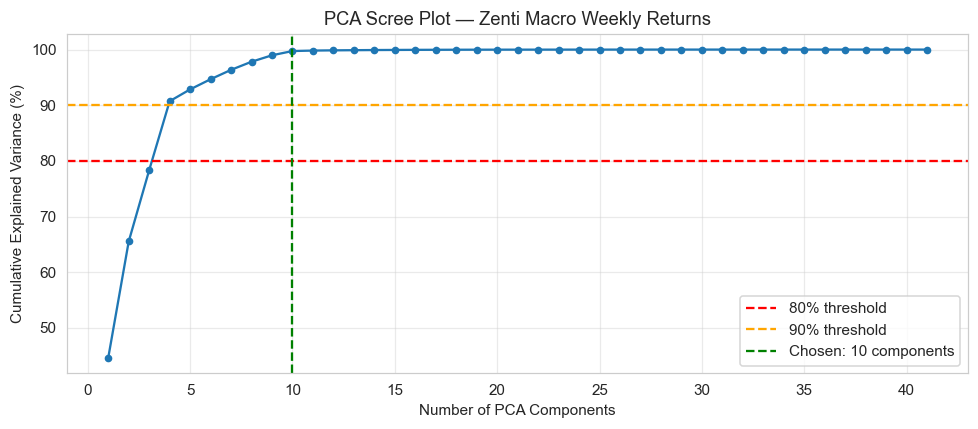

Explained variance with 10 components: 99.7%


In [9]:
# Weekly returns already computed above as df_returns; reuse it
print(f"Returns matrix shape: {df_returns.shape}  (observations × features)")

N_COMPONENTS = 10   # PCA components; adjust based on elbow plot below

# Elbow plot — cumulative explained variance
n_max = min(df_returns.shape[1] - 1, df_returns.shape[0] - 1)
pca_full = PCA(n_components=n_max, svd_solver='auto', random_state=42)
pca_full.fit(df_returns)
explained = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(explained) + 1), explained * 100, marker='o', markersize=4)
ax.axhline(80, color='red',    linestyle='--', label='80% threshold')
ax.axhline(90, color='orange', linestyle='--', label='90% threshold')
ax.axvline(N_COMPONENTS, color='green', linestyle='--', label=f'Chosen: {N_COMPONENTS} components')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA Scree Plot — Zenti Macro Weekly Returns')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Explained variance with {N_COMPONENTS} components: {explained[N_COMPONENTS-1]*100:.1f}%")

In [10]:
# pca_full was already fit above on all components — reuse it instead of fitting again.
# pca_full.components_ has shape (n_max, 42); slicing the first N_COMPONENTS rows and
# transposing gives (42, N_COMPONENTS): one row per feature, columns are PCA loadings.
X_pca    = pca_full.components_[:N_COMPONENTS].T     # (42 features, N_COMPONENTS)
X_scaled = preprocessing.StandardScaler().fit_transform(X_pca)

print(f"PCA output shape : {X_pca.shape}")
print(f"Scaled shape     : {X_scaled.shape}")

PCA output shape : (42, 10)
Scaled shape     : (42, 10)


## 5. OPTICS Clustering

**Why OPTICS?** Unlike k-means, OPTICS is a density-based algorithm that:
- Does **not require specifying k** upfront
- Handles clusters of **irregular shape and varying density**
- Assigns low-density points to a **noise class** (label `-1`) rather than forcing them into a cluster

**Why cluster at all?** With 42 features there are ~861 possible pairs. Most have no economic rationale for cointegration. Clustering restricts the search to pairs whose return dynamics are genuinely similar — reducing spurious tests and improving statistical power.

`min_samples` controls how tight a neighbourhood must be to form a core point. Lower values → more, smaller clusters. Higher values → fewer, denser clusters + more noise.

In [11]:
def run_optics(X, df_returns, min_samples=3):
    """
    Cluster features using OPTICS on PCA-reduced return space.
    Returns clustered_series_all (all features), clustered_series (non-noise only),
    counts (features per cluster), and the fitted OPTICS object.
    """
    clf = OPTICS(min_samples=min_samples)
    clf.fit(X)
    labels = clf.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    clustered_series_all = pd.Series(index=df_returns.columns, data=labels.flatten())
    clustered_series     = clustered_series_all[clustered_series_all != -1]
    counts               = clustered_series.value_counts()

    print(f"Clusters discovered : {n_clusters}")
    print(f"Features assigned   : {len(clustered_series)} / {len(clustered_series_all)}")
    print(f"Noise features      : {(labels == -1).sum()}")
    print(f"Pairs to evaluate   : {int((counts * (counts - 1) / 2).sum())}")
    return clustered_series_all, clustered_series, counts, clf


clustered_series_all, clustered_series, counts, clf = run_optics(X_scaled, df_returns, min_samples=3)
# min_samples=3 → 2 clusters (fine-grained); min_samples=6+ → 1 large cluster

Clusters discovered : 2
Features assigned   : 10 / 42
Noise features      : 32
Pairs to evaluate   : 20


## 6. Cluster Visualization

### 6.1 Cluster Sizes

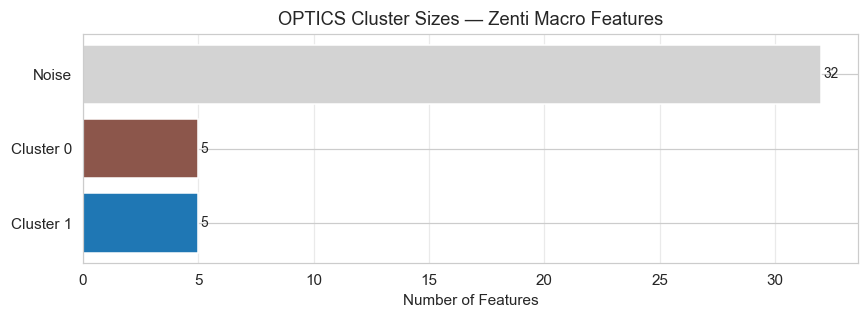

In [12]:
n_clusters = len(counts)
noise_count = (clustered_series_all == -1).sum()

labels_plot = [f'Cluster {i}' for i in counts.index] + (['Noise'] if noise_count > 0 else [])
sizes_plot  = list(counts.values) + ([noise_count] if noise_count > 0 else [])
colors_plot = [cm.tab10(i / max(n_clusters, 1)) for i in range(len(counts))] + (['lightgray'] if noise_count > 0 else [])

fig, ax = plt.subplots(figsize=(8, max(3, len(labels_plot) * 0.6)))
bars = ax.barh(labels_plot, sizes_plot, color=colors_plot, edgecolor='white')
for bar, val in zip(bars, sizes_plot):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Number of Features')
ax.set_title('OPTICS Cluster Sizes — Zenti Macro Features')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

### 6.2 Per-Cluster Feature Table

In [13]:
for label_n in sorted(clustered_series.unique()):
    members = list(clustered_series[clustered_series == label_n].index)
    print(f"\nCluster {label_n}  ({len(members)} features):")
    print(f"  {'Feature':<15} {'Asset Type'}")
    print(f"  {'-'*15} {'-'*25}")
    for feat in members:
        print(f"  {feat:<15} {feature_types.get(feat, 'Unknown')}")

noise_feats = list(clustered_series_all[clustered_series_all == -1].index)
if noise_feats:
    print(f"\nNoise (unclustered):")
    for feat in noise_feats:
        print(f"  {feat:<15} {feature_types.get(feat, 'Unknown')}")


Cluster 0  (5 features):
  Feature         Asset Type
  --------------- -------------------------
  JPY             Currency
  LF98TRUU        Bond Index
  LG30TRUU        Bond Index
  LP01TREU        Bond Index
  MXEU            Equity Index

Cluster 1  (5 features):
  Feature         Asset Type
  --------------- -------------------------
  DXY             Currency
  EMUSTRUU        Bond Index
  LMBITR          Bond Index
  LUACTRUU        Bond Index
  LUMSTRUU        Bond Index

Noise (unclustered):
  BDIY            Economic Index
  CRY             Commodity Index
  Cl1             Commodity
  ECSURPUS        Economic Index
  EONIA           Interest rate
  GBP             Currency
  GT10            Bond Yield
  GTDEM10Y        Bond Yield
  GTDEM2Y         Bond Yield
  GTDEM30Y        Bond Yield
  GTGBP20Y        Bond Yield
  GTGBP2Y         Bond Yield
  GTGBP30Y        Bond Yield
  GTITL10YR       Bond Yield
  GTITL2YR        Bond Yield
  GTITL30YR       Bond Yield
  GTJPY10YR    

### 6.4 Normalized Time Series per Cluster

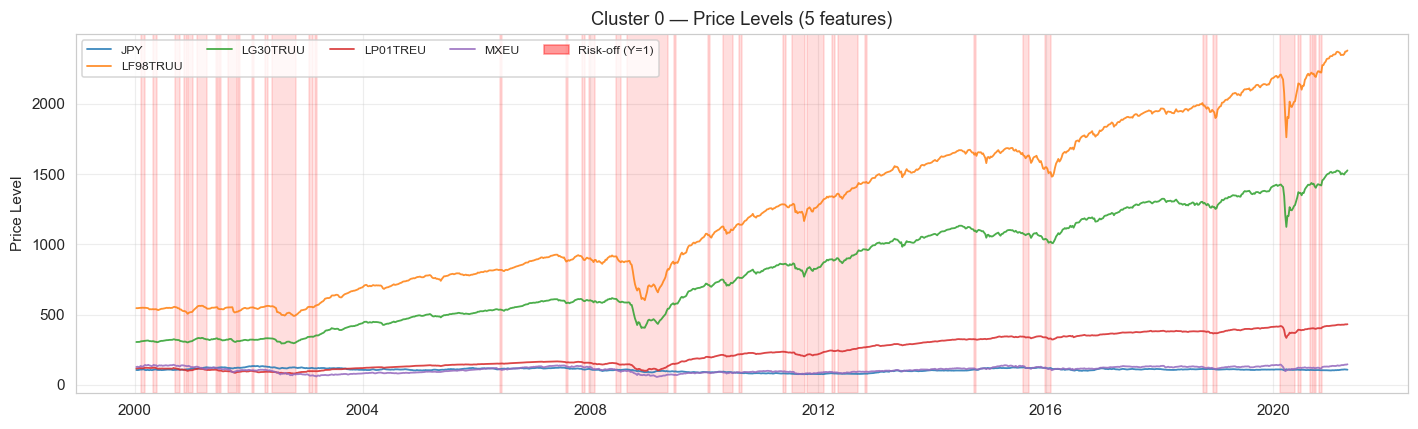

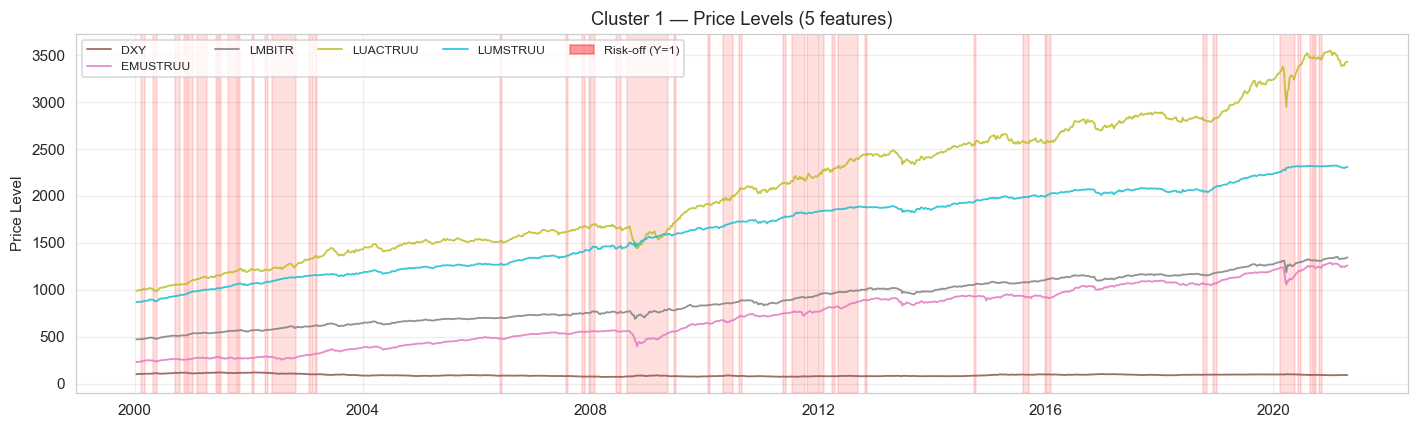

In [15]:
CLUSTER_COLORS = [
    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],  # Cluster 0
    ['#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'],  # Cluster 1
]

for label_n in sorted(clustered_series.unique()):
    members = list(clustered_series[clustered_series == label_n].index)
    colors  = CLUSTER_COLORS[label_n % len(CLUSTER_COLORS)]

    fig, ax = plt.subplots(figsize=(13, 4))

    for idx, col in enumerate(members):
        ax.plot(df_prices.index, df_prices[col],
                label=col, color=colors[idx % len(colors)],
                linewidth=1.2, alpha=0.85)

    shade_risk_off(ax, y_labels, alpha=0.13)

    handles, lbls = ax.get_legend_handles_labels()
    handles.append(mpatches.Patch(color='red', alpha=0.4, label='Risk-off (Y=1)'))
    ax.legend(handles=handles, loc='upper left', fontsize=8, ncol=min(5, len(members) + 1))
    ax.set_title(f'Cluster {label_n} — Price Levels ({len(members)} features)')
    ax.set_ylabel('Price Level')
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()

## 7. Pair Selection Helper Functions

Four statistical filters applied sequentially to each candidate pair:

| Function | What it measures | Accept if |
|---|---|---|
| `stationarity` | ADF test — is the spread stationary? | p-value < threshold |
| `hurst_exp` | Hurst exponent — is the spread mean-reverting? | H < 0.5 (ideally); we allow up to 0.55 |
| `half_life` | Ornstein-Uhlenbeck half-life (OLS regression of Δspread on lagged spread) | Within [MIN, MAX] weeks |
| `zero_crossings` | How often the spread crosses its mean | ≥ MIN (confirms active mean reversion) |

The **half-life** formula comes from fitting `Δz_t = α + β·z_{t-1} + ε`. If β < 0, the spread is mean-reverting with half-life = −ln(2)/β. A half-life too short means noise; too long means the series barely reverts within a tradeable horizon.

In [16]:
def stationarity(X):
    """ADF test — returns t-statistic, p-value, and critical values."""
    adf = ADF(X)
    return {'t_statistic': adf.stat, 'p_value': adf.pvalue, 'critical_values': adf.critical_values}


def hurst_exp(ts):
    """
    Hurst exponent: H < 0.5 → mean-reverting, H = 0.5 → random walk, H > 0.5 → trending.
    Returns 0.9 on failure so the pair is automatically rejected (above HURST_THRESHOLD).
    """
    try:
        H, c, data = compute_Hc(ts, kind='price', simplified=False)
        return H
    except Exception:
        return 0.9


def half_life(z_array):
    """
    Estimates the Ornstein-Uhlenbeck half-life from Δz_t = α + β·z_{t-1} + ε.
    β < 0 implies mean reversion; half-life = −ln(2) / β (in the same time units as the data).
    """
    z_lag = np.roll(z_array, 1)
    z_lag[0] = 0
    z_ret = z_array - z_lag
    z_ret[0] = 0
    z_lag2 = sm.add_constant(z_lag)
    model = sm.OLS(z_ret[1:], z_lag2[1:])
    res = model.fit()
    hl = -np.log(2) / res.params[1]
    return hl


def zero_crossings(x):
    """Counts how many times the demeaned spread crosses zero — a proxy for mean-reversion activity."""
    x = x - x.mean()
    return sum(
        1 for i, _ in enumerate(x)
        if (i + 1 < len(x)) and ((x[i] * x[i + 1] < 0) or (x[i] == 0))
    )


print("Helper functions defined: stationarity, hurst_exp, half_life, zero_crossings")

Helper functions defined: stationarity, hurst_exp, half_life, zero_crossings


## 8. Pair Selection Thresholds (Adapted for Weekly Data)

The reference project used intraday bars; our data is **weekly**. Thresholds are scaled accordingly:

- **ADF p-value < 0.10**: slightly relaxed from the standard 0.05 — macro spreads are noisy and a strict 5% cut would eliminate too many economically valid pairs
- **Hurst < 0.55**: H = 0.5 is a pure random walk, H < 0.5 is mean-reverting. We allow up to 0.55 to account for estimation noise on weekly data
- **Half-life 2–156 weeks**: lower bound = 2 weeks (anything faster is microstructure noise at weekly resolution); upper bound = 3 years (beyond that, the spread reverts too slowly to be useful as an anomaly signal)
- **Zero crossings ≥ 12**: ensures the spread has crossed its mean at least ~once per year on average over the full sample

In [17]:
P_VALUE_THRESHOLD  = 0.10   # cointegration spread must have ADF p-value < 0.10
HURST_THRESHOLD    = 0.55   # H=0.5 is random walk, H<0.5 mean-reverting; 0.55 allows for weekly estimation noise
MIN_HALF_LIFE      = 2      # weeks
MAX_HALF_LIFE      = 156    # weeks (3 years)
MIN_ZERO_CROSSINGS = 12

## 9. Pair Selection Loop

For every pair within each cluster, we apply five criteria **in sequence** — a pair is rejected as soon as it fails one:

1. **Both legs non-stationary** (ADF p > 0.10 on each price level)
2. **Cointegration** — OLS regression of S1 on S2 (and vice versa); the residual spread must be stationary (ADF p < 0.10) with a positive beta. Both directions are tested and the one with the stronger t-statistic is kept.
3. **Hurst exponent** of the spread < 0.55
4. **Half-life** of mean reversion within [2, 156] weeks
5. **Zero crossings** ≥ 12

The pair parameters saved for each passing pair (beta, spread series, Hurst, half-life, zero crossings) are what the downstream LSTM notebook will use to construct and model the spread.

In [18]:
CRIT_KEYS = ['cointegration', 'hurst_exponent', 'half_life', 'mean_cross', 'None']

clusters_pairs = {clust: [] for clust in range(n_clusters)}
clusters_fail  = {clust: {k: 0 for k in CRIT_KEYS} for clust in range(n_clusters)}
total_pairs    = []
total_fail     = {k: 0 for k in CRIT_KEYS}

HDR = (f"{'Pair':<22} {'ADF_S1':>7} {'ADF_S2':>7} {'Coint_p':>8} "
       f"{'Beta':>6} {'Hurst':>6} {'HL(wk)':>7} {'ZC':>4}  Result")
SEP = '-' * len(HDR)

for clust in sorted(clustered_series.unique()):
    symbols    = list(clustered_series[clustered_series == clust].index)
    cluster_df = df_prices[symbols]
    n          = cluster_df.shape[1]
    keys       = cluster_df.columns

    print(f"\n{'='*len(HDR)}")
    print(f"Cluster {clust}: {n} features → {n*(n-1)//2} pairs to test")
    print(f"  Features: {list(symbols)}")
    print(HDR)
    print(SEP)

    for i in range(n):
        for j in range(i + 1, n):
            S1 = cluster_df[keys[i]]
            S2 = cluster_df[keys[j]]
            label = f"{keys[i][:10]}/{keys[j][:10]}"

            row = {'adf1': '---', 'adf2': '---', 'coint_p': '---',
                   'beta': '---', 'H': '---', 'hl': '---', 'zc': '---',
                   'result': ''}

            combinations  = [(S1, S2), (S2, S1)]
            betas         = [None, None]
            spreads       = [None, None]
            spread_arrays = [None, None]
            pair_stats    = [None, None]
            crit_fail     = 'cointegration'

            # Criterion 1: both legs non-stationary — use pre-computed cache
            pval1 = adf_cache[keys[i]]
            pval2 = adf_cache[keys[j]]
            row['adf1'] = f"{pval1:.3f}"
            row['adf2'] = f"{pval2:.3f}"

            if pval1 > P_VALUE_THRESHOLD and pval2 > P_VALUE_THRESHOLD:
                best_coint_p = 1.0
                for k, (dep, indep) in enumerate(combinations):
                    res_ols = sm.OLS(np.asarray(dep),
                                     sm.add_constant(np.asarray(indep))).fit()
                    b = res_ols.params[1]
                    betas[k] = b
                    if b > 0:
                        sp  = dep - b * indep
                        spa = np.asarray(sp)
                        spreads[k]       = sp
                        spread_arrays[k] = spa
                        st_sp = stationarity(spa)
                        if st_sp['p_value'] < P_VALUE_THRESHOLD:
                            pair_stats[k] = {
                                't_statistic' : st_sp['t_statistic'],
                                'critical_val': st_sp['critical_values'],
                                'p_value'     : st_sp['p_value']
                            }
                        if st_sp['p_value'] < best_coint_p:
                            best_coint_p = st_sp['p_value']
                            row['coint_p'] = f"{st_sp['p_value']:.3f}"
                            row['beta']    = f"{b:.3f}"

            # Pick direction with stronger ADF t-statistic; None if neither cointegrates
            valid = [k for k, ps in enumerate(pair_stats) if ps is not None]
            if not valid:
                result = None
            else:
                result = max(valid, key=lambda k: abs(pair_stats[k]['t_statistic']))

            if result is not None:
                spread_arr = spread_arrays[result]
                params     = pair_stats[result]
                crit_fail  = 'hurst_exponent'

                H = hurst_exp(spread_arr)
                row['H'] = f"{H:.3f}"

                if H < HURST_THRESHOLD:
                    crit_fail = 'half_life'
                    hl = half_life(spread_arr)
                    row['hl'] = f"{hl:.1f}" if np.isfinite(hl) else 'inf'

                    if MIN_HALF_LIFE <= hl < MAX_HALF_LIFE:
                        crit_fail = 'mean_cross'
                        zc = zero_crossings(spread_arr)
                        row['zc'] = str(zc)

                        if zc >= MIN_ZERO_CROSSINGS:
                            crit_fail = 'None'
                            params['coint_coef']     = betas[result]
                            params['spread']         = spreads[result]
                            params['zero_cross']     = zc
                            params['half_life']      = int(round(hl))
                            params['hurst_exponent'] = H
                            params['S1']             = combinations[result][1]
                            params['S2']             = combinations[result][0]
                            params['cluster']        = int(clust)
                            clusters_pairs[clust].append((keys[i], keys[j], params))

            fail_map = {
                'cointegration' : 'FAIL coint',
                'hurst_exponent': 'FAIL Hurst',
                'half_life'     : 'FAIL HL',
                'mean_cross'    : 'FAIL ZC',
                'None'          : 'PASS'
            }
            row['result'] = fail_map[crit_fail]
            clusters_fail[clust][crit_fail] += 1

            print(f"{label:<22} {row['adf1']:>7} {row['adf2']:>7} {row['coint_p']:>8} "
                  f"{row['beta']:>6} {row['H']:>6} {row['hl']:>7} {row['zc']:>4}  {row['result']}")

    total_pairs.extend(clusters_pairs[clust])
    for crit in CRIT_KEYS:
        total_fail[crit] += clusters_fail[clust][crit]

    print(f"\n  → {len(clusters_pairs[clust])} pairs accepted in Cluster {clust}")

print(f"\n{'='*len(HDR)}")
print(f"TOTAL PAIRS FOUND: {len(total_pairs)}")


Cluster 0: 5 features → 10 pairs to test
  Features: ['JPY', 'LF98TRUU', 'LG30TRUU', 'LP01TREU', 'MXEU']
Pair                    ADF_S1  ADF_S2  Coint_p   Beta  Hurst  HL(wk)   ZC  Result
----------------------------------------------------------------------------------
JPY/LF98TRUU             0.401   0.994      ---    ---    ---     ---  ---  FAIL coint
JPY/LG30TRUU             0.401   0.987      ---    ---    ---     ---  ---  FAIL coint
JPY/LP01TREU             0.401   0.989      ---    ---    ---     ---  ---  FAIL coint
JPY/MXEU                 0.401   0.390    0.345  0.636    ---     ---  ---  FAIL coint
LF98TRUU/LG30TRUU        0.994   0.987    0.159  0.668    ---     ---  ---  FAIL coint
LF98TRUU/LP01TREU        0.994   0.989    0.539  0.197    ---     ---  ---  FAIL coint
LF98TRUU/MXEU            0.994   0.390    0.104  0.019    ---     ---  ---  FAIL coint
LG30TRUU/LP01TREU        0.987   0.989    0.091  3.343  0.508    82.0   45  PASS
LG30TRUU/MXEU            0.987   0.390

## 10. Results Summary & Save

We print a failure breakdown (how many pairs were eliminated at each criterion) and display a summary table of the accepted pairs with their key statistics.

The 4 accepted pairs are saved to:
- **`total_pairs_zenti.pkl`** — list of `(feat1, feat2, params_dict)` tuples consumed by the LSTM notebook
- **`pair_selection_summary.csv`** — human-readable table for inspection

The spread plots below show the cointegration spread (z-scored) for each passing pair, with risk-off periods shaded in red — a visual sanity check that the spread diverges during stress events.

In [19]:
# ── Failure breakdown ────────────────────────────────────────────────────────
print("Failure breakdown (pairs rejected at each criterion):")
crit_labels = {
    'cointegration' : 'Criterion 1+2 — Non-stationary / Cointegration',
    'hurst_exponent': 'Criterion 3   — Hurst exponent ≥ 0.5',
    'half_life'     : 'Criterion 4   — Half-life out of range',
    'mean_cross'    : 'Criterion 5   — Too few zero crossings',
    'None'          : 'PASSED all criteria'
}
for k, v in total_fail.items():
    print(f"  {crit_labels[k]:<55}: {v}")

print(f"\nPer-cluster results:")
for clust in range(n_clusters):
    n_found  = len(clusters_pairs[clust])
    n_tested = sum(clusters_fail[clust].values())
    print(f"  Cluster {clust}: {n_found} pairs found / {n_tested} tested")

Failure breakdown (pairs rejected at each criterion):
  Criterion 1+2 — Non-stationary / Cointegration         : 15
  Criterion 3   — Hurst exponent ≥ 0.5                   : 1
  Criterion 4   — Half-life out of range                 : 0
  Criterion 5   — Too few zero crossings                 : 0
  PASSED all criteria                                    : 4

Per-cluster results:
  Cluster 0: 2 pairs found / 10 tested
  Cluster 1: 2 pairs found / 10 tested


In [20]:
# ── Summary DataFrame ────────────────────────────────────────────────────────
if total_pairs:
    rows = []
    for feat1, feat2, p in total_pairs:
        rows.append({
            'Feature1'       : feat1,
            'Type1'          : feature_types.get(feat1, 'Unknown'),
            'Feature2'       : feat2,
            'Type2'          : feature_types.get(feat2, 'Unknown'),
            'Cluster'        : p['cluster'],
            't_statistic'    : round(p['t_statistic'], 4),
            'p_value'        : round(p['p_value'], 4),
            'hurst_exponent' : round(p['hurst_exponent'], 4),
            'half_life_wks'  : p['half_life'],
            'zero_crossings' : p['zero_cross'],
            'coint_coef'     : round(p['coint_coef'], 4),
        })
    summary_df = pd.DataFrame(rows).sort_values(['Cluster', 'p_value'])
    display(summary_df.reset_index(drop=True))
else:
    print("No pairs found. Consider relaxing MAX_HALF_LIFE to 156 weeks or P_VALUE_THRESHOLD to 0.10.")
    summary_df = pd.DataFrame()

,Feature1,Type1,Feature2,Type2,Cluster,t_statistic,p_value,hurst_exponent,half_life_wks,zero_crossings,coint_coef
0,LG30TRUU,Bond Index,LP01TREU,Bond Index,0,-2.6078,0.0914,0.5077,82,45,3.3426
1,LP01TREU,Bond Index,MXEU,Equity Index,0,-2.5761,0.0980,0.5493,64,32,0.1008
2,EMUSTRUU,Bond Index,LMBITR,Bond Index,1,-3.6061,0.0056,0.5054,25,59,0.7754
3,LMBITR,Bond Index,LUACTRUU,Bond Index,1,-3.1064,0.0261,0.5351,32,58,0.3483


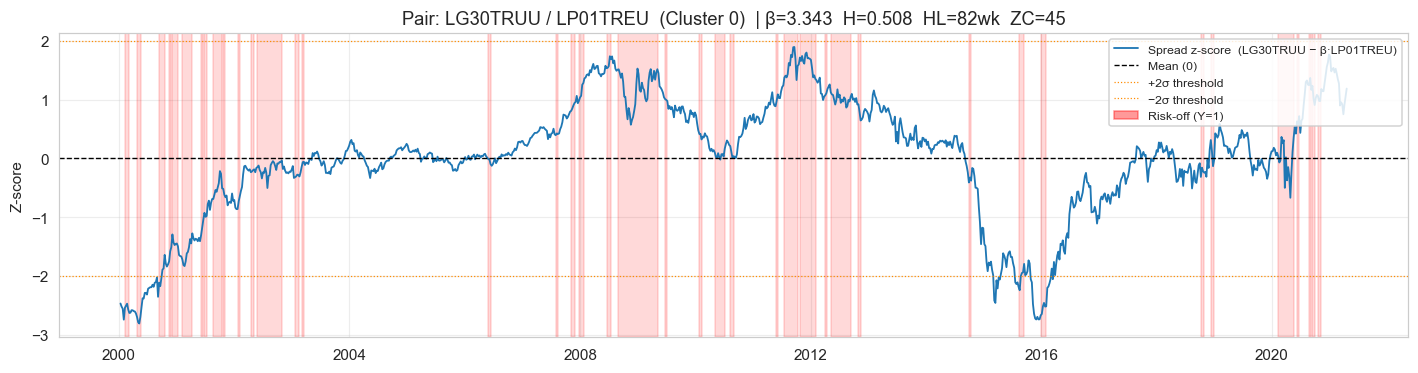

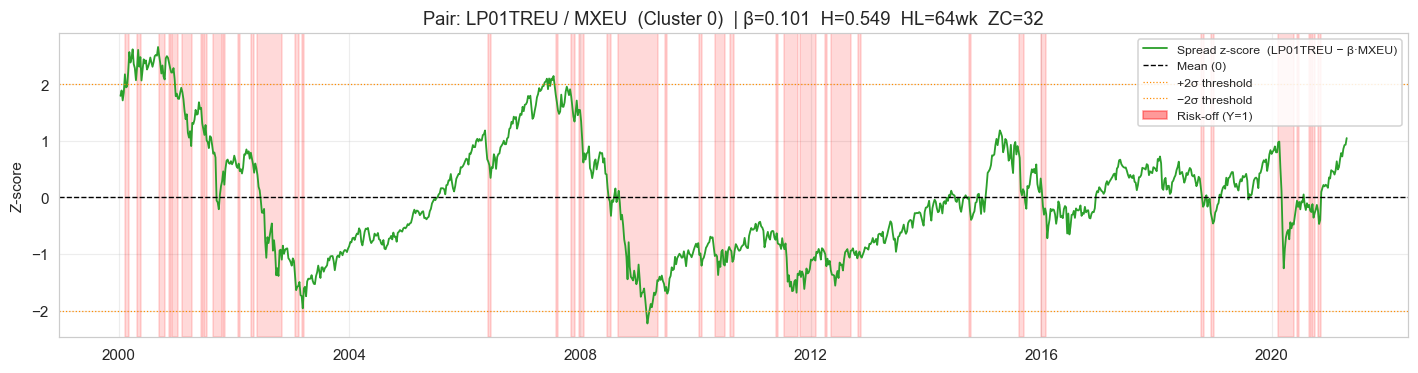

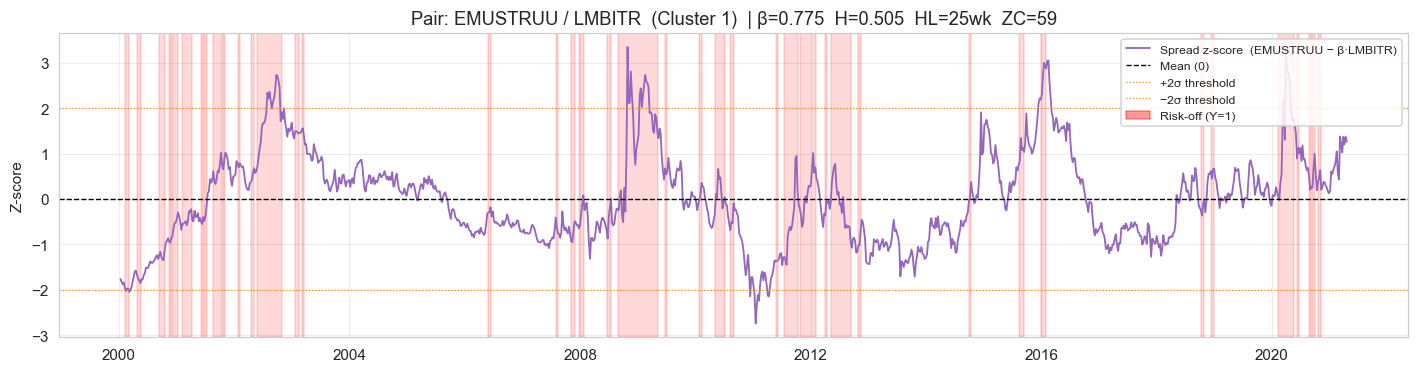

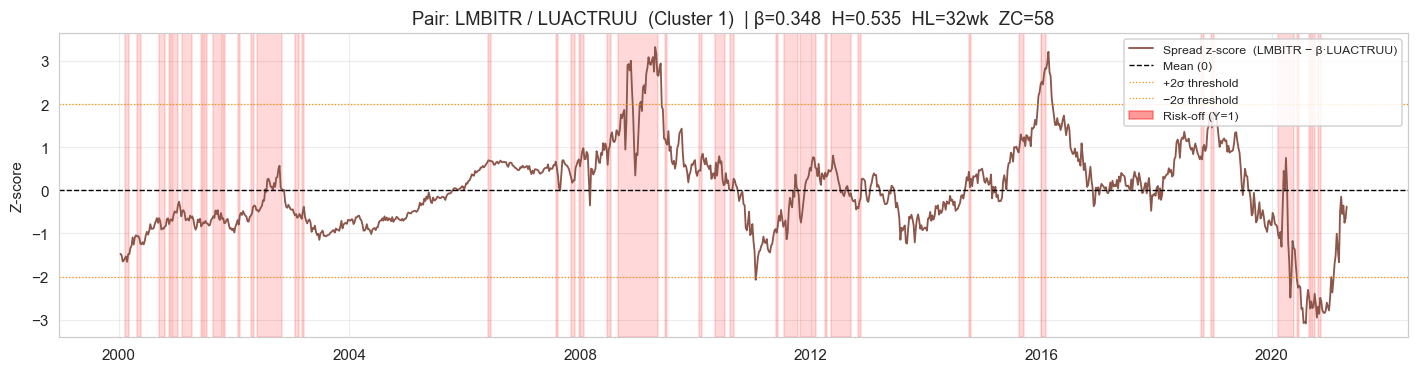

In [21]:
PAIR_COLORS = ['#1f77b4', '#2ca02c', '#9467bd', '#8c564b']

if total_pairs:
    for pair_idx, (feat1, feat2, p) in enumerate(total_pairs):
        spread   = p['spread']
        spread_z = (spread - spread.mean()) / spread.std()
        color    = PAIR_COLORS[pair_idx % len(PAIR_COLORS)]

        fig, ax = plt.subplots(figsize=(13, 3.5))

        ax.plot(spread.index, spread_z, linewidth=1.2, color=color,
                label=f'Spread z-score  ({feat1} − β·{feat2})')
        ax.axhline(0,  color='black',     linewidth=0.9, linestyle='--', label='Mean (0)')
        ax.axhline( 2, color='darkorange', linewidth=0.8, linestyle=':',  label='+2σ threshold')
        ax.axhline(-2, color='darkorange', linewidth=0.8, linestyle=':',  label='−2σ threshold')

        shade_risk_off(ax, y_labels, alpha=0.15)

        handles, lbls = ax.get_legend_handles_labels()
        handles.append(mpatches.Patch(color='red', alpha=0.4, label='Risk-off (Y=1)'))
        ax.set_title(
            f"Pair: {feat1} / {feat2}  (Cluster {p['cluster']})  "
            f"| β={p['coint_coef']:.3f}  H={p['hurst_exponent']:.3f}  "
            f"HL={p['half_life']}wk  ZC={p['zero_cross']}"
        )
        ax.set_ylabel('Z-score')
        ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.85)
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.show()

In [22]:
with open(OUTPUT_PATH + 'total_pairs_zenti.pkl', 'wb') as f:
    pickle.dump(total_pairs, f)
print(f"Saved: total_pairs_zenti.pkl  ({len(total_pairs)} pairs)")

if not summary_df.empty:
    summary_df.to_csv(OUTPUT_PATH + 'pair_selection_summary.csv', index=False)
    print("Saved: pair_selection_summary.csv")

Saved: total_pairs_zenti.pkl  (4 pairs)
Saved: pair_selection_summary.csv
